# FINAL PROJECT ASSIGNMENT  
> Course: Data Analysis with Python  

### Project No. 02: Telco Customer Churn Prediction

---

#### **Authors**: Group 9

| No. | Full Name | Student ID |
|-----|------------|-------------|
| 1 | Đinh Vân Anh | 11247123 |
| 2 | Phạm Thùy Anh | 11247137 |
| 3 | Nguyễn Hoàng Hà | 11247162 |
| 4 | Hoàng Thị Lệ Xuân | 11247249 |

---

#### **Supervisor:** Dr. Tran Hung







## Step 1. Understand the problem and the dataset


### 1.1 Download dataset from Kaggle

We use the **Kaggle API** to download the dataset directly into this notebook.

> **One-time setup required:**
> 1. Go to [https://www.kaggle.com/settings](https://www.kaggle.com/settings) → **Legacy API Credentials** section → click **"Create Legacy API Key"**.
> 2. This downloads a file called `kaggle.json` containing your credentials.
> 3. Run the cell below and **upload** that `kaggle.json` when prompted. Your credentials are stored only for this session.
>
> If you already have `kaggle.json` in your Google Drive, you can mount Drive and copy it instead.

In [ ]:
# Install the Kaggle API client
!pip install -q kaggle

import os
from google.colab import files

# Upload your kaggle.json credentials
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Place credentials where the Kaggle API expects them
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "wb") as f:
    f.write(list(uploaded.values())[0])
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("✅ Kaggle credentials saved.")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle (1).json
✅ Kaggle credentials saved.


In [ ]:
# Download the Telco Customer Churn dataset from Kaggle
!kaggle datasets download -d blastchar/telco-customer-churn --unzip

# Confirm the file is present
import glob
csv_files = glob.glob("*.csv")
print("Downloaded CSV files:", csv_files)

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 106MB/s]

Downloaded CSV files: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']


### 1.2 Import libraries & Load the data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# Load the dataset
df_raw = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully.")
print("Shape:", df_raw.shape)
df_raw.head()

Dataset loaded successfully.
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.3 Problem description and practical meaning

**What is customer churn?**

Customer churn refers to the phenomenon where customers stop using a company's service. In the context of a telecommunications (telco) company, churn means a subscriber cancels or does not renew their contract.

**Why is this problem important in practice?**

- Acquiring a new customer is significantly more expensive than retaining an existing one (industry estimates range from 5× to 25× more costly).
- High churn rates directly reduce revenue and signal customer dissatisfaction.
- By predicting which customers are likely to churn, the company can proactively offer targeted retention incentives (discounts, improved plans, personalized support) before the customer leaves.
- This makes churn prediction one of the most commercially valuable applications of machine learning in the telecom industry.

**Problem type:** Binary classification — predict whether a customer will churn (`Yes`) or not (`No`).

### 1.4 Target variable identification

Target variable: Churn

Value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Class distribution (%):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


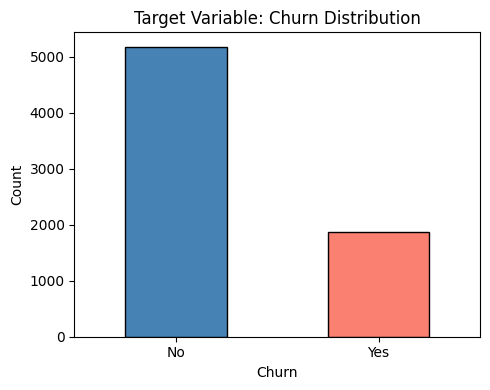


Interpretation:
  - 'Yes' means the customer churned (left the company).
  - 'No'  means the customer is still active.
  The dataset is imbalanced — churned customers represent ~26% of the total.
  This imbalance will need to be considered during modeling.



In [ ]:
# The target variable is 'Churn'
print("Target variable: Churn")
print()
print("Value counts:")
print(df_raw["Churn"].value_counts())
print()
print("Class distribution (%):")
print(df_raw["Churn"].value_counts(normalize=True).mul(100).round(2))

# Visualize target distribution
fig, ax = plt.subplots(figsize=(5, 4))
df_raw["Churn"].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "salmon"], edgecolor="black")
ax.set_title("Target Variable: Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - 'Yes' means the customer churned (left the company).
  - 'No'  means the customer is still active.
  The dataset is imbalanced — churned customers represent ~26% of the total.
  This imbalance will need to be considered during modeling.
""")

### 1.5 Feature overview

The dataset contains **21 columns** covering four main categories of information:

| Category | Features |
|---|---|
| **Customer demographics** | `customerID`, `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| **Account information** | `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges` |
| **Phone services** | `PhoneService`, `MultipleLines` |
| **Internet services** | `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` |
| **Target** | `Churn` |

**Key input features:**
- `tenure` – How long the customer has been with the company (months)
- `MonthlyCharges` – The monthly fee paid by the customer
- `TotalCharges` – Total amount charged over the customer's lifetime
- `Contract` – Type of contract (Month-to-month, One year, Two year)
- `InternetService` – Type of internet service subscribed
- `PaymentMethod` – How the customer pays their bill

### 1.6 Dataset shape, column names, and data types

In [ ]:
print("=" * 50)
print(f"Number of rows    : {df_raw.shape[0]}")
print(f"Number of columns : {df_raw.shape[1]}")
print("=" * 50)

Number of rows    : 7043
Number of columns : 21


In [ ]:
# Column names and data types
print("Column names and data types:")
print(df_raw.dtypes)

Column names and data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [ ]:
# Count by dtype category
print("\nData type summary:")
print(df_raw.dtypes.value_counts())


Data type summary:
object     18
int64       2
float64     1
Name: count, dtype: int64


### 1.7 First statistical inspection

In [ ]:
# Missing values per column
print("Missing values per column:")
missing = df_raw.isna().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No NaN values detected at this stage.")
print(f"\nTotal missing cells: {df_raw.isna().sum().sum()}")

Missing values per column:
No NaN values detected at this stage.

Total missing cells: 0


In [ ]:
# Descriptive statistics for numeric columns
print("Descriptive statistics (numeric columns):")
df_raw.describe()

Descriptive statistics (numeric columns):


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# Descriptive statistics for all columns including categorical
print("Full descriptive statistics (all columns):")
df_raw.describe(include="all")

Full descriptive statistics (all columns):


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [ ]:
# Unique value counts for categorical columns — helpful for spotting inconsistencies
categorical_cols = df_raw.select_dtypes(include="object").columns.tolist()
print("Unique values per categorical column:")
for col in categorical_cols:
    vals = sorted(df_raw[col].dropna().unique().tolist())
    print(f"  {col} ({len(vals)} unique): {vals[:10]}{'...' if len(vals) > 10 else ''}")

Unique values per categorical column:
  customerID (7043 unique): ['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ', '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS']...
  gender (2 unique): ['Female', 'Male']
  Partner (2 unique): ['No', 'Yes']
  Dependents (2 unique): ['No', 'Yes']
  PhoneService (2 unique): ['No', 'Yes']
  MultipleLines (3 unique): ['No', 'No phone service', 'Yes']
  InternetService (3 unique): ['DSL', 'Fiber optic', 'No']
  OnlineSecurity (3 unique): ['No', 'No internet service', 'Yes']
  OnlineBackup (3 unique): ['No', 'No internet service', 'Yes']
  DeviceProtection (3 unique): ['No', 'No internet service', 'Yes']
  TechSupport (3 unique): ['No', 'No internet service', 'Yes']
  StreamingTV (3 unique): ['No', 'No internet service', 'Yes']
  StreamingMovies (3 unique): ['No', 'No internet service', 'Yes']
  Contract (3 unique): ['Month-to-month', 'One year', 'Two year']
  PaperlessBilling (2 unique): ['No', 'Yes']
  PaymentMe

In [ ]:
# Check TotalCharges specifically — it is stored as object (string), not float
# This is a known quirk of this dataset
print("TotalCharges dtype:", df_raw["TotalCharges"].dtype)
print("\nSample values:")
print(df_raw["TotalCharges"].head(10).tolist())

# Check for non-numeric entries
non_numeric_tc = df_raw[pd.to_numeric(df_raw["TotalCharges"], errors="coerce").isna()]
print(f"\nRows where TotalCharges cannot be converted to float: {len(non_numeric_tc)}")
print(non_numeric_tc[["customerID", "TotalCharges"]].head(10))

TotalCharges dtype: object

Sample values:
['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95']

Rows where TotalCharges cannot be converted to float: 11
      customerID TotalCharges
488   4472-LVYGI             
753   3115-CZMZD             
936   5709-LVOEQ             
1082  4367-NUYAO             
1340  1371-DWPAZ             
3331  7644-OMVMY             
3826  3213-VVOLG             
4380  2520-SGTTA             
5218  2923-ARZLG             
6670  4075-WKNIU             


In [ ]:
# Check for duplicate rows
n_full_dups = df_raw.duplicated().sum()
n_id_dups   = df_raw.duplicated(subset=["customerID"]).sum()
print(f"Fully duplicated rows   : {n_full_dups}")
print(f"Duplicate customerIDs   : {n_id_dups}")

Fully duplicated rows   : 0
Duplicate customerIDs   : 0


In [ ]:
# SeniorCitizen is 0/1 integer — confirm encoding
print("SeniorCitizen unique values:", df_raw["SeniorCitizen"].unique())
print("SeniorCitizen dtype:", df_raw["SeniorCitizen"].dtype)
print("\nNote: SeniorCitizen is stored as int (0 = No, 1 = Yes), unlike other binary columns which use 'Yes'/'No' strings.")

SeniorCitizen unique values: [0 1]
SeniorCitizen dtype: int64

Note: SeniorCitizen is stored as int (0 = No, 1 = Yes), unlike other binary columns which use 'Yes'/'No' strings.


### 1.8 Summary of Key Observations

| Observation | Detail |
|---|---|
| Dataset size | 7,043 rows × 21 columns |
| Target variable | `Churn` (binary: Yes / No, ~26% churn rate) |
| No NaN values visible | But hidden missing values exist (whitespace strings in `TotalCharges`) |
| `TotalCharges` stored as `object` | Must be converted to `float64`; whitespace entries are missing values |
| `SeniorCitizen` stored as `int` | Should be treated as categorical (0/1 or Yes/No) |
| No fully duplicate rows | `customerID` appears unique |
| `customerID` is an identifier | Should be dropped before modeling |

## Step 2. Data cleaning

### 2.1 Make a working copy


We never modify the raw dataset. All cleaning is performed on a copy so we can always compare against the original.

In [ ]:
df = df_raw.copy()
print("Working copy created.")
print("Shape:", df.shape)

Working copy created.
Shape: (7043, 21)


### 2.2 Standardize missing-value representations

In this dataset, missing values are not stored as `NaN` — they appear as **whitespace strings** (a single space `' '`), particularly in `TotalCharges`. We convert these to proper `NaN` so pandas can handle them correctly.

In [ ]:
# Replace whitespace-only strings and common placeholders with NaN
df = df.replace(r'^\s*$', np.nan, regex=True)
df = df.replace(["none", "None", "N/A", "n/a", "unknown", "Unknown", ""], np.nan)

# Re-check missing values
print("Missing values per column after standardization:")
missing_after = df.isna().sum()
print(missing_after[missing_after > 0])
print(f"\nTotal missing cells: {df.isna().sum().sum()}")

Missing values per column after standardization:
TotalCharges    11
dtype: int64

Total missing cells: 11


### 2.3 Handle missing values

**Strategy:**
- `TotalCharges` is numeric — we will convert it first, then fill missing values with the **median** (safer than mean in case of outliers).
- These missing rows correspond to customers with `tenure = 0` (new customers who have not yet been charged), so filling with median is a reasonable approximation. Alternatively, we could fill with `0` — we document our choice here.

In [ ]:
# First: convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("TotalCharges dtype after conversion:", df["TotalCharges"].dtype)
print("Missing TotalCharges after conversion:", df["TotalCharges"].isna().sum())

TotalCharges dtype after conversion: float64
Missing TotalCharges after conversion: 11


In [ ]:
# Inspect the rows with missing TotalCharges
missing_tc = df[df["TotalCharges"].isna()]
print("Rows with missing TotalCharges:")
display(missing_tc[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

Rows with missing TotalCharges:


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [ ]:
# All missing TotalCharges rows have tenure = 0 (brand-new customers)
# We fill with the median of existing TotalCharges values
median_tc = df["TotalCharges"].median()
print(f"Median TotalCharges: {median_tc:.2f}")

df.loc[:, "TotalCharges"] = df["TotalCharges"].fillna(median_tc)
print(f"Missing TotalCharges after fill: {df['TotalCharges'].isna().sum()}")

Median TotalCharges: 1397.47
Missing TotalCharges after fill: 0


In [ ]:
# Final check — no more missing values should remain
print("Missing values per column (final check):")
remaining_missing = df.isna().sum()
if remaining_missing.sum() == 0:
    print("✅ No missing values remain.")
else:
    print(remaining_missing[remaining_missing > 0])

Missing values per column (final check):
✅ No missing values remain.


### 2.4 Remove duplicate rows

`customerID` is the unique identifier for each customer. Duplicate `customerID` values would mean the same customer appears more than once, which would distort counts and model training.

The inspection in Step 1 has already confirmed that customerID is unique and free of duplicates.

### 2.5 Correct data types

After inspection in Step 1, we identified two columns with incorrect types:
- `TotalCharges` — already fixed in Step 2.3 (converted to `float64`)
- `SeniorCitizen` — stored as `int64` (0/1) but represents a binary categorical variable like `Partner` and `Dependents`

In [ ]:
print("Data types before correction:")
print(df.dtypes)

Data types before correction:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [ ]:
# Convert SeniorCitizen from int (0/1) to string 'Yes'/'No' for consistency with other binary attributes
df.loc[:, "SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
print("SeniorCitizen after conversion:", df["SeniorCitizen"].unique())

# Confirm TotalCharges is now float
print("TotalCharges dtype:", df["TotalCharges"].dtype)

print("\nData types after correction:")
print(df.dtypes)

SeniorCitizen after conversion: ['No' 'Yes']
TotalCharges dtype: float64

Data types after correction:
customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


/tmp/ipykernel_2835/991725692.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['No' 'No' 'No' ... 'No' 'Yes' 'No']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, "SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})


### 2.6 Detect and repair invalid / abnormal values

We define business rules for the numeric columns based on domain knowledge:

| Column | Valid range | Reasoning |
|---|---|---|
| `tenure` | 0 – 72 | Max contract length in dataset is 72 months |
| `MonthlyCharges` | 0 – 200 | Reasonable upper bound for telco plans |
| `TotalCharges` | 0 – 15,000 | tenure × MonthlyCharges upper bound |

In [ ]:
# Check range of numeric columns
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
print("Numeric column ranges:")
print(df[numeric_cols].agg(["min", "max", "mean", "median"]))

Numeric column ranges:
           tenure  MonthlyCharges  TotalCharges
min      0.000000       18.250000     18.800000
max     72.000000      118.750000   8684.800000
mean    32.371149       64.761692   2281.916928
median  29.000000       70.350000   1397.475000


In [ ]:
# Check for invalid tenure values (negative or impossibly large)
invalid_tenure = df[(df["tenure"] < 0) | (df["tenure"] > 72)]
print(f"Invalid tenure values: {len(invalid_tenure)}")

# Check for invalid MonthlyCharges
invalid_monthly = df[(df["MonthlyCharges"] <= 0) | (df["MonthlyCharges"] > 200)]
print(f"Invalid MonthlyCharges values: {len(invalid_monthly)}")

# Check for invalid TotalCharges
invalid_total = df[(df["TotalCharges"] < 0) | (df["TotalCharges"] > 15000)]
print(f"Invalid TotalCharges values: {len(invalid_total)}")

print("\n✅ No invalid numeric values found." if (len(invalid_tenure) + len(invalid_monthly) + len(invalid_total) == 0) else "⚠️ Some invalid values detected — inspect above.")

Invalid tenure values: 0
Invalid MonthlyCharges values: 0
Invalid TotalCharges values: 0

✅ No invalid numeric values found.


In [ ]:
# IQR-based outlier detection for the three numeric columns
print("IQR Outlier Detection\n" + "-" * 40)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}, bounds=[{lower:.1f}, {upper:.1f}], outliers={len(outliers)}")

IQR Outlier Detection
----------------------------------------
tenure: Q1=9.0, Q3=55.0, IQR=46.0, bounds=[-60.0, 124.0], outliers=0
MonthlyCharges: Q1=35.5, Q3=89.8, IQR=54.3, bounds=[-46.0, 171.4], outliers=0
TotalCharges: Q1=402.2, Q3=3786.6, IQR=3384.4, bounds=[-4674.3, 8863.2], outliers=0


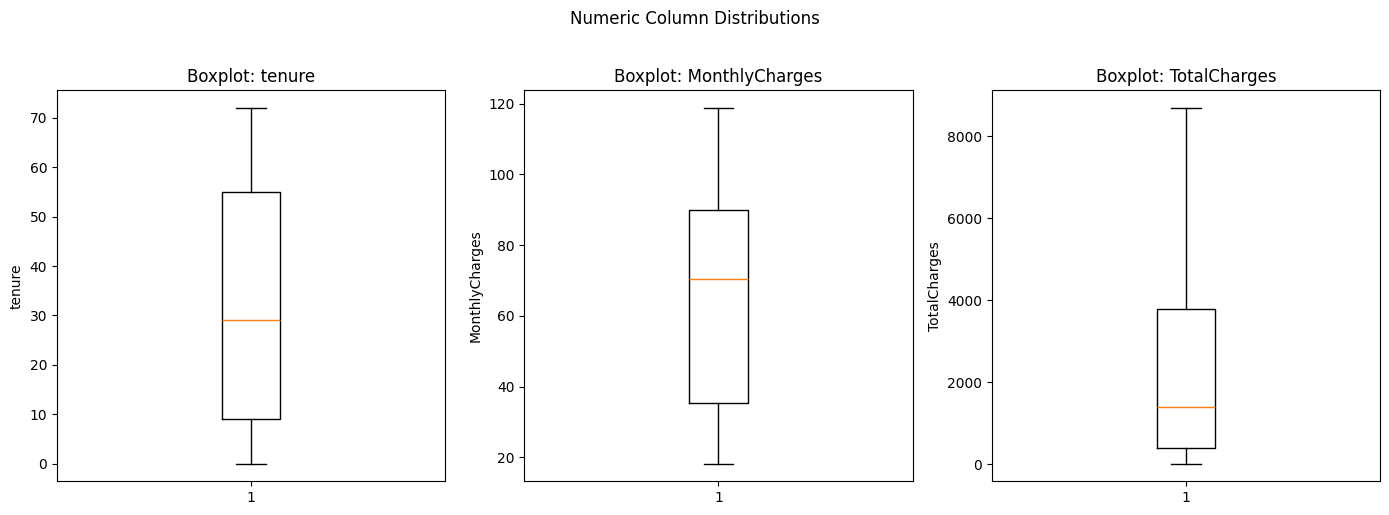


Interpretation:
  - tenure: spread from 0 to 72 months; the distribution reflects the full range of customer lifetimes.
  - MonthlyCharges: wide range due to different service tiers — no true outliers, just natural variation.
  - TotalCharges: right-skewed, as expected (long-tenure customers accumulate higher totals).
  No values need to be removed or corrected based on business rules.



In [ ]:
# Visualize distributions using box plots
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(f"Boxplot: {col}")
    ax.set_ylabel(col)
plt.suptitle("Numeric Column Distributions", y=1.02)
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - tenure: spread from 0 to 72 months; the distribution reflects the full range of customer lifetimes.
  - MonthlyCharges: wide range due to different service tiers — no true outliers, just natural variation.
  - TotalCharges: right-skewed, as expected (long-tenure customers accumulate higher totals).
  No values need to be removed or corrected based on business rules.
""")

### 2.7 Unnecessary columns

The `customerID` column is a unique identifier with no predictive value for modeling. It should be noted and can be dropped before feeding data into a model. We keep it in the cleaned dataset for traceability but flag it here.

### 2.8 Standardize categorical text values

We check all `object`-type columns for inconsistent labels (mixed case, leading/trailing spaces, abbreviations, etc.).

In [ ]:
# Strip leading/trailing whitespace from all text columns
text_cols = df.select_dtypes(include="object").columns.tolist()
for col in text_cols:
    df.loc[:, col] = df[col].astype(str).str.strip()
print("Whitespace stripped from:", text_cols)

Whitespace stripped from: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [ ]:
# Check unique values after stripping
print("Unique values per categorical column after stripping:")
for col in text_cols:
    if col == "customerID":
        continue
    vals = sorted(df[col].dropna().unique().tolist())
    print(f"  {col}: {vals}")

Unique values per categorical column after stripping:
  gender: ['Female', 'Male']
  SeniorCitizen: ['No', 'Yes']
  Partner: ['No', 'Yes']
  Dependents: ['No', 'Yes']
  PhoneService: ['No', 'Yes']
  MultipleLines: ['No', 'No phone service', 'Yes']
  InternetService: ['DSL', 'Fiber optic', 'No']
  OnlineSecurity: ['No', 'No internet service', 'Yes']
  OnlineBackup: ['No', 'No internet service', 'Yes']
  DeviceProtection: ['No', 'No internet service', 'Yes']
  TechSupport: ['No', 'No internet service', 'Yes']
  StreamingTV: ['No', 'No internet service', 'Yes']
  StreamingMovies: ['No', 'No internet service', 'Yes']
  Contract: ['Month-to-month', 'One year', 'Two year']
  PaperlessBilling: ['No', 'Yes']
  PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
  Churn: ['No', 'Yes']


In [ ]:
# The Churn column uses 'Yes'/'No' — confirm consistency
print("Churn unique values:", df["Churn"].unique())

# All binary Yes/No columns — confirm consistent labels
binary_cols = ["gender", "Partner", "Dependents", "PhoneService",
               "PaperlessBilling", "Churn", "SeniorCitizen"]
print("\nBinary column value checks:")
for col in binary_cols:
    vals = sorted(df[col].unique().tolist())
    print(f"  {col}: {vals}")

Churn unique values: ['No' 'Yes']

Binary column value checks:
  gender: ['Female', 'Male']
  Partner: ['No', 'Yes']
  Dependents: ['No', 'Yes']
  PhoneService: ['No', 'Yes']
  PaperlessBilling: ['No', 'Yes']
  Churn: ['No', 'Yes']
  SeniorCitizen: ['No', 'Yes']


In [ ]:
# Service columns use 'Yes', 'No', 'No internet service', 'No phone service'
# These are consistent and correct — no mapping needed
service_cols = ["MultipleLines", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
print("Service column unique values:")
for col in service_cols:
    print(f"  {col}: {sorted(df[col].unique().tolist())}")

Service column unique values:
  MultipleLines: ['No', 'No phone service', 'Yes']
  OnlineSecurity: ['No', 'No internet service', 'Yes']
  OnlineBackup: ['No', 'No internet service', 'Yes']
  DeviceProtection: ['No', 'No internet service', 'Yes']
  TechSupport: ['No', 'No internet service', 'Yes']
  StreamingTV: ['No', 'No internet service', 'Yes']
  StreamingMovies: ['No', 'No internet service', 'Yes']


In [ ]:
# Check Contract, InternetService, PaymentMethod
for col in ["Contract", "InternetService", "PaymentMethod"]:
    print(f"  {col}: {sorted(df[col].unique().tolist())}")

  Contract: ['Month-to-month', 'One year', 'Two year']
  InternetService: ['DSL', 'Fiber optic', 'No']
  PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']


In [ ]:
# All categorical labels are already clean and consistent.
# No remapping required for this dataset.
print("✅ All categorical columns have consistent, clean labels. No remapping needed.")

✅ All categorical columns have consistent, clean labels. No remapping needed.


### 2.9 Rule-based validation summary

After all cleaning steps, we verify that the dataset satisfies all business rules before declaring it clean.

In [ ]:
valid_gender        = {"Male", "Female"}
valid_churn         = {"Yes", "No"}
valid_contract      = {"Month-to-month", "One year", "Two year"}
valid_internet      = {"DSL", "Fiber optic", "No"}
valid_senior        = {"Yes", "No"}

validation_results = {
    "customerID_unique"         : df["customerID"].is_unique,
    "no_missing_values"         : df.isna().sum().sum() == 0,
    "tenure_valid_range"        : df["tenure"].between(0, 72).all(),
    "MonthlyCharges_positive"   : (df["MonthlyCharges"] > 0).all(),
    "TotalCharges_non_negative" : (df["TotalCharges"] >= 0).all(),
    "gender_valid_values"       : df["gender"].isin(valid_gender).all(),
    "Churn_valid_values"        : df["Churn"].isin(valid_churn).all(),
    "Contract_valid_values"     : df["Contract"].isin(valid_contract).all(),
    "InternetService_valid"     : df["InternetService"].isin(valid_internet).all(),
    "SeniorCitizen_valid"       : df["SeniorCitizen"].isin(valid_senior).all(),
}

print("Validation Results:")
print("-" * 45)
all_passed = True
for rule, result in validation_results.items():
    status = "✅ PASS" if result else "❌ FAIL"
    print(f"  {status}  {rule}")
    if not result:
        all_passed = False

print("-" * 45)
print("All rules passed!" if all_passed else "⚠️  Some rules failed — inspect above.")

Validation Results:
---------------------------------------------
  ✅ PASS  customerID_unique
  ✅ PASS  no_missing_values
  ✅ PASS  tenure_valid_range
  ✅ PASS  MonthlyCharges_positive
  ✅ PASS  TotalCharges_non_negative
  ✅ PASS  gender_valid_values
  ✅ PASS  Churn_valid_values
  ✅ PASS  Contract_valid_values
  ✅ PASS  InternetService_valid
  ✅ PASS  SeniorCitizen_valid
---------------------------------------------
All rules passed!


### 2.10 Compare raw vs cleaned data

In [ ]:
print(f"Raw data shape    : {df_raw.shape}")
print(f"Cleaned data shape: {df.shape}")
print()
print("Changes made during cleaning:")
print(f"  - Rows removed (duplicates)            : {df_raw.shape[0] - df.shape[0]}")
print(f"  - TotalCharges converted to float64    : yes")
print(f"  - TotalCharges missing values filled   : {df_raw['TotalCharges'].replace(r'^\\s*$', np.nan, regex=True).apply(pd.to_numeric, errors='coerce').isna().sum()} rows → median")
print(f"  - SeniorCitizen converted to Yes/No    : yes")
print(f"  - Whitespace stripped (all text cols)  : yes")
print(f"  - No additional label standardization  : labels were already consistent")

Raw data shape    : (7043, 21)
Cleaned data shape: (7043, 21)

Changes made during cleaning:
  - Rows removed (duplicates)            : 0
  - TotalCharges converted to float64    : yes
  - TotalCharges missing values filled   : 11 rows → median
  - SeniorCitizen converted to Yes/No    : yes
  - Whitespace stripped (all text cols)  : yes
  - No additional label standardization  : labels were already consistent


In [ ]:
print("Raw data (first 5 rows):")
display(df_raw.head())
print("\nCleaned data (first 5 rows):")
display(df.head())

Raw data (first 5 rows):


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Cleaned data (first 5 rows):


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Final data types
print("Final data types:")
print(df.dtypes)

Final data types:
customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [ ]:
# Save the cleaned dataset for the next steps
df.to_csv("telco_churn_cleaned.csv", index=False)
print("✅ Cleaned dataset saved to 'telco_churn_cleaned.csv'")
print(f"   Shape: {df.shape}")

✅ Cleaned dataset saved to 'telco_churn_cleaned.csv'
   Shape: (7043, 21)


## Step 3. Exploratory Data Analysis (EDA)

In [ ]:
# 1. Load the cleaned dataset
df_cleaned = pd.read_csv('telco_churn_cleaned.csv')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.dpi'] = 120

# Set a consistent and modern style for all plots
sns.set_theme(style="whitegrid")
modern_palette = ["#2A9D8F", "#E76F51"]

### Descriptive Statistics

In [ ]:
# 1. Descriptive statistics for numerical features
print("=" * 80)
print("1. DESCRIPTIVE STATISTICS FOR NUMERICAL FEATURES")
print("=" * 80)

display(df_cleaned.describe())

print("\n")

# 2. Descriptive statistics for categorical features
print("=" * 80)
print("2. DESCRIPTIVE STATISTICS FOR CATEGORICAL FEATURES")
print("=" * 80)

display(df_cleaned.describe(include=['object', 'category']))

1. DESCRIPTIVE STATISTICS FOR NUMERICAL FEATURES


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000




2. DESCRIPTIVE STATISTICS FOR CATEGORICAL FEATURES


,customerID,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,5901,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


### 📋 Descriptive Statistics — Observations

Based on the statistical outputs above, we draw the following initial observations
before proceeding to visual analysis.

---

**1. Numerical Features**

- **`tenure`**: Customers have been with the company for an average of **32.4 months**
  (std = 24.6), indicating high variability. The median (50th percentile = 29 months)
  is close to the mean, suggesting a roughly symmetric distribution — though the wide
  range (0 to 72 months) reflects a mix of very new and very long-term customers.

- **`MonthlyCharges`**: The average monthly bill is **$64.76$**, ranging from $18.25$
  to $118.75$ (std = $30.09$). The interquartile range ($35.50$ – $89.85$) is quite wide,
  suggesting that customers subscribe to significantly different service tiers.

- **`TotalCharges`**: Highly right-skewed — the mean ($2,281.92$) is substantially
  higher than the median ($1,397.48$), indicating that a smaller group of long-tenure,
  high-spending customers pulls the average upward. The std ($2,265.27$) is nearly
  equal to the mean, reflecting extreme variance driven by differences in tenure length.

---

**2. Categorical Features**

- **Gender**: The dataset is nearly gender-balanced — 3,555 males vs. 3,488 females —
  so gender is unlikely to be a strong differentiating factor on its own.

- **Contract type**: `Month-to-month` is the most common contract (3,875 customers,
  ~55% of total), suggesting that the majority of the customer base has **no long-term
  commitment**, which may contribute to the elevated churn rate observed in the target.

- **Internet Service**: `Fiber optic` is the most subscribed service (3,096 customers),
  slightly outnumbering DSL. This is notable because fiber optic users tend to pay
  higher monthly charges.

- **Add-on services**: Across `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`,
  `TechSupport`, `StreamingTV`, and `StreamingMovies`, the most frequent value is
  consistently **"No"** — meaning the majority of customers have not subscribed to
  these additional services. This low adoption rate may be a contributing factor to
  lower perceived value and higher churn.

- **Payment Method**: `Electronic check` is the most common payment method (2,365
  customers), which — as will be explored further in the visual analysis — is also
  the method most associated with churn.

- **Target Variable (`Churn`)**: Out of 7,043 customers, **5,174 (73.5%) have not
  churned** and **1,869 (26.5%) have churned**. This moderate class imbalance should
  be accounted for during model training and evaluation — accuracy alone will not be
  a sufficient performance metric.

### Chart 1: Distribution of the Target Variable (Churn)
First, we need to understand the balance of our target variable, `Churn`.

In [ ]:
import plotly.graph_objects as go

# ============================================================
# CHART 1: Churn Distribution (Target Variable Overview)
# Understanding class imbalance is the first step in any
# classification EDA. ~26% churn rate indicates imbalanced data.
# ============================================================

# Prepare the data
churn_counts = df_cleaned['Churn'].value_counts()
c_labels = churn_counts.index.tolist()  # ['No', 'Yes']
c_values = churn_counts.values.tolist()

modern_colors = ['#2A9D8F', '#E76F51']

# Create the donut chart
fig = go.Figure(data=[go.Pie(
    labels=c_labels,
    values=c_values,
    name="Churn",
    hole=0.4,
    marker=dict(colors=modern_colors, line=dict(color='#FFFFFF', width=2)), # Adding white borders for a cleaner look
    hoverinfo="label+percent+name",
    textinfo="percent", # Shows only percentage on the chart
    textfont_size=16
)])

# Update layout for title and center annotation
fig.update_layout(
    title_text="Customer Churn Distribution",
    title_x=0.5,  # Center the title
    # Add annotation in the exact center of the donut pie
    annotations=[dict(
        text='Churn',
        x=0.5,
        y=0.5,
        font_size=22,
        font_weight="bold",
        showarrow=False
    )],
    # Make the background clean and modern
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)'
)

# Display the chart
fig.show()

#### Observations: Churn Distribution

- The chart reveals that **26.54%** of the customer base has churned, while the remaining **73.46%** continue to use the service.

- This distribution indicates a class imbalance in our target variable. To prevent the predictive model from becoming biased towards the majority class (`No`), this imbalance must be addressed during the data preprocessing or model training phases (e.g., using oversampling or class weighting).

- Despite the imbalance, a churn rate where more than 1 in 4 customers leave is **significantly high**. This signals a critical customer retention problem that requires immediate strategic intervention to minimize revenue loss.

### Chart 2: Distribution of Numerical Features by Churn

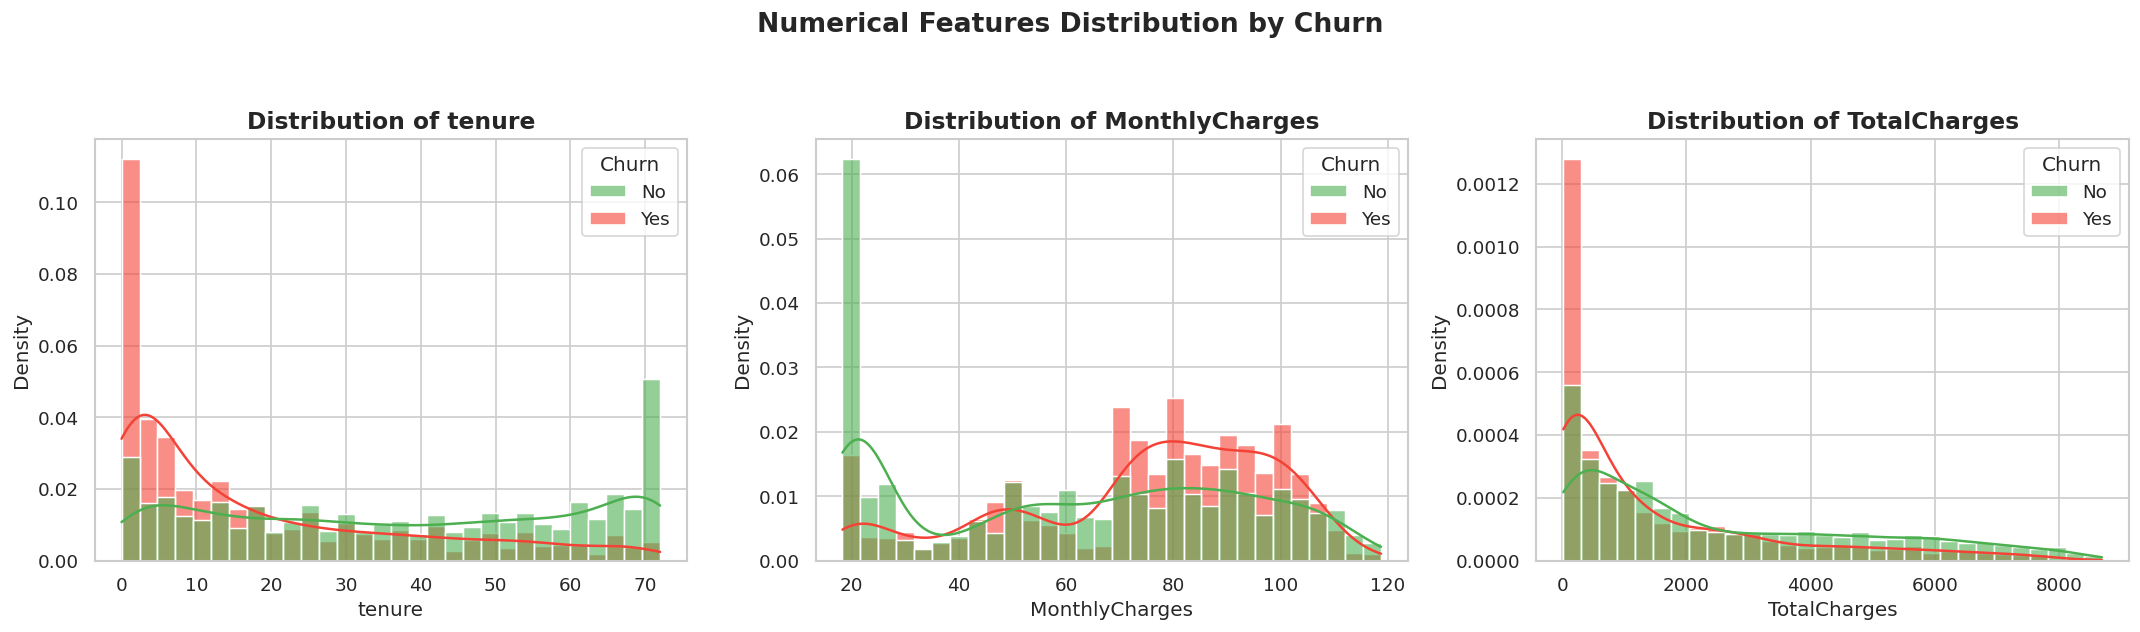

In [ ]:
# ============================================================
# CHART 2: Distribution of Numerical Features by Churn
# Churned customers tend to have shorter tenure and higher
# monthly charges — key signal for early-warning models.
# ============================================================
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_features):
    sns.histplot(data=df_cleaned, x=col, hue='Churn', kde=True, bins=30,
                 palette=['#4CAF50', '#F44336'], # Xanh lá cho No, Đỏ cho Yes
                 alpha=0.6, ax=axes[i], stat='density', common_norm=False)

    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Density', fontsize=12)

plt.suptitle('Numerical Features Distribution by Churn', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

#### Observations: Distribution of Numerical Features by Churn

- **Tenure**: Churned customers are heavily concentrated at **low tenure values (0–10 months)**, while retained customers are more evenly spread across all tenure ranges. This suggests that **new customers are at the highest risk of churning**.
- **Monthly Charges**: Customers who churned tend to have **higher monthly charges**, with the distribution skewed toward the $70–100+$ range. This may indicate dissatisfaction with pricing relative to perceived value.
- **Total Charges**: Retained customers show a wider and higher distribution of total charges, which is consistent with their longer tenure — they have simply been paying longer.
- Overall, **tenure and monthly charges are strong numerical predictors** of churn and should be prioritized in feature selection.

### Chart 3: Churn Rate by Key Categorical Features

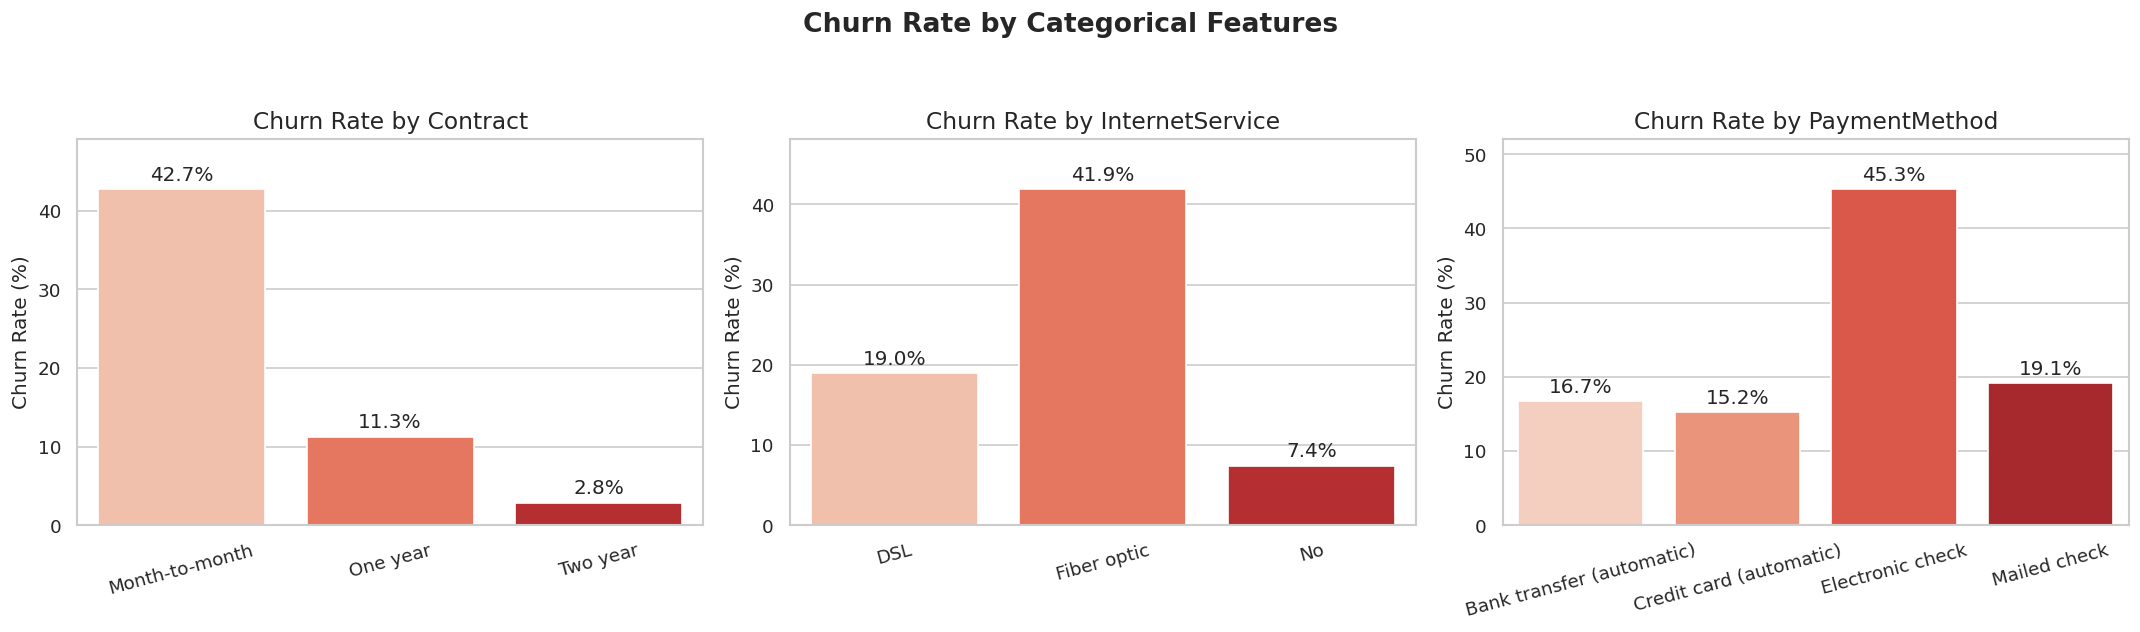

In [ ]:
# ============================================================
# CHART 3: Churn Rate by Key Categorical Features
# Month-to-month contracts show dramatically higher churn.
# Fiber optic internet users churn more than DSL users.
# Electronic check payment correlates with higher churn.
# ============================================================
cat_features = ['Contract', 'InternetService', 'PaymentMethod']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_features):
    churn_pct = df_cleaned.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    churn_pct.columns = [col, 'ChurnRate']

    sns.barplot(data=churn_pct, x=col, y='ChurnRate', hue=col, palette='Reds', legend=False, ax=axes[i])

    axes[i].set_title(f'Churn Rate by {col}', fontsize=14)
    axes[i].set_ylabel('Churn Rate (%)', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

    # Add percentage labels on top of the bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f%%', label_type='edge', padding=3)

    # Adjust y-axis limit to create more whitespace above the bars
    max_churn_rate = churn_pct['ChurnRate'].max()
    axes[i].set_ylim(0, max_churn_rate * 1.15) # Set y-limit to 15% above max churn rate

plt.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

#### Observations: Churn Rate by Key Categorical Features

- **Contract Type**: **Month-to-month** contract customers have a churn rate of  **42.7%**, compared to only **11.3% for one-year** and **2.8% for two-year** contracts. Longer commitments are strongly associated with customer retention.
- **Internet Service**: **Fiber optic users** exhibit a notably higher churn rate (**41.9%**) compared to **DSL users** (**19%**). This may reflect **unmet quality expectations or higher pricing** associated with fiber plans.
- **Payment Method**: Customers paying via **electronic check churn at the highest rate (45.3%)**, while those using automatic payment methods (bank transfer, credit card) churn significantly less (~15–17%). Automatic payments may reduce friction and increase loyalty. Interestingly, mailed check users show a moderate churn rate (19.1%), which may indicate a more stable or traditional customer segment that is less sensitive to service changes despite using non-automatic payment methods.
- These three features are among the **most actionable variables** for designing targeted retention campaigns.

### Chart 4: Tenure by Churn

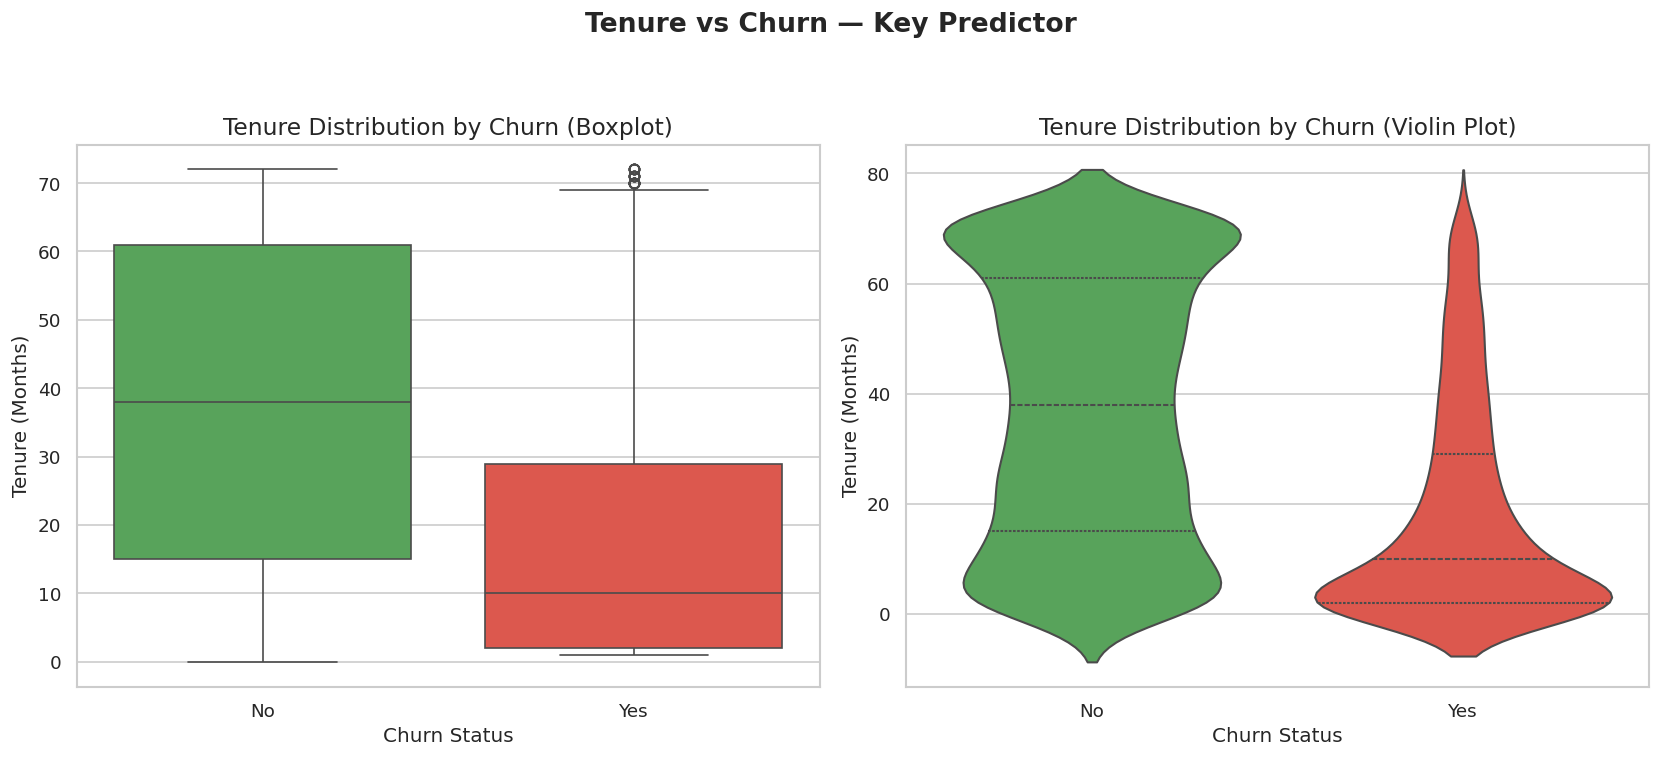

In [ ]:
# ============================================================
# CHART 4: Tenure by Churn (Box + Violin Plot)
# INSIGHT: Customers who churn have significantly lower tenure
# (median ~10 months) vs retained customers (median ~38 months).
# Early-stage customers are highest risk — target for intervention.
# ============================================================

# Create subplots for Boxplot and Violin plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Define the color palette (Green for 'No' / Retained, Red for 'Yes' / Churned)
churn_palette = ['#4CAF50', '#F44336']

# ---------------------------------------------------------
# Subplot 1: Boxplot (Focuses on statistical summaries: Median, Quartiles)
# ---------------------------------------------------------
sns.boxplot(data=df_cleaned, x='Churn', y='tenure', hue='Churn', palette=churn_palette, legend=False, ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn (Boxplot)', fontsize=14)
axes[0].set_xlabel('Churn Status', fontsize=12)
axes[0].set_ylabel('Tenure (Months)', fontsize=12)

# ---------------------------------------------------------
# Subplot 2: Violin Plot (Focuses on data density and distribution shape)
# ---------------------------------------------------------
sns.violinplot(data=df_cleaned, x='Churn', y='tenure', hue='Churn', palette=churn_palette,
               inner='quartile', legend=False, ax=axes[1])
axes[1].set_title('Tenure Distribution by Churn (Violin Plot)', fontsize=14)
axes[1].set_xlabel('Churn Status', fontsize=12)
axes[1].set_ylabel('Tenure (Months)', fontsize=12)

# Set the main overarching title for the entire figure
plt.suptitle('Tenure vs Churn — Key Predictor', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

#### Observations: Tenure vs Churn

- The boxplot clearly shows that **churned customers have a median tenure of approximately 10 months**, compared to **~38 months for retained customers** — indicating a substantial gap in customer longevity.
- The violin plot reveals that the churn group is **heavily concentrated at very low tenure values**, with the distribution tapering off sharply after 20 months.
- This confirms that the **first 12 months are the most critical retention window** — interventions such as onboarding support, loyalty discounts, or proactive outreach should be prioritized for new customers.
- Very few customers with tenure beyond 50 months tend to churn, indicating that **long-term customers are relatively stable**.

### Chart 5: Correlation Heatmap

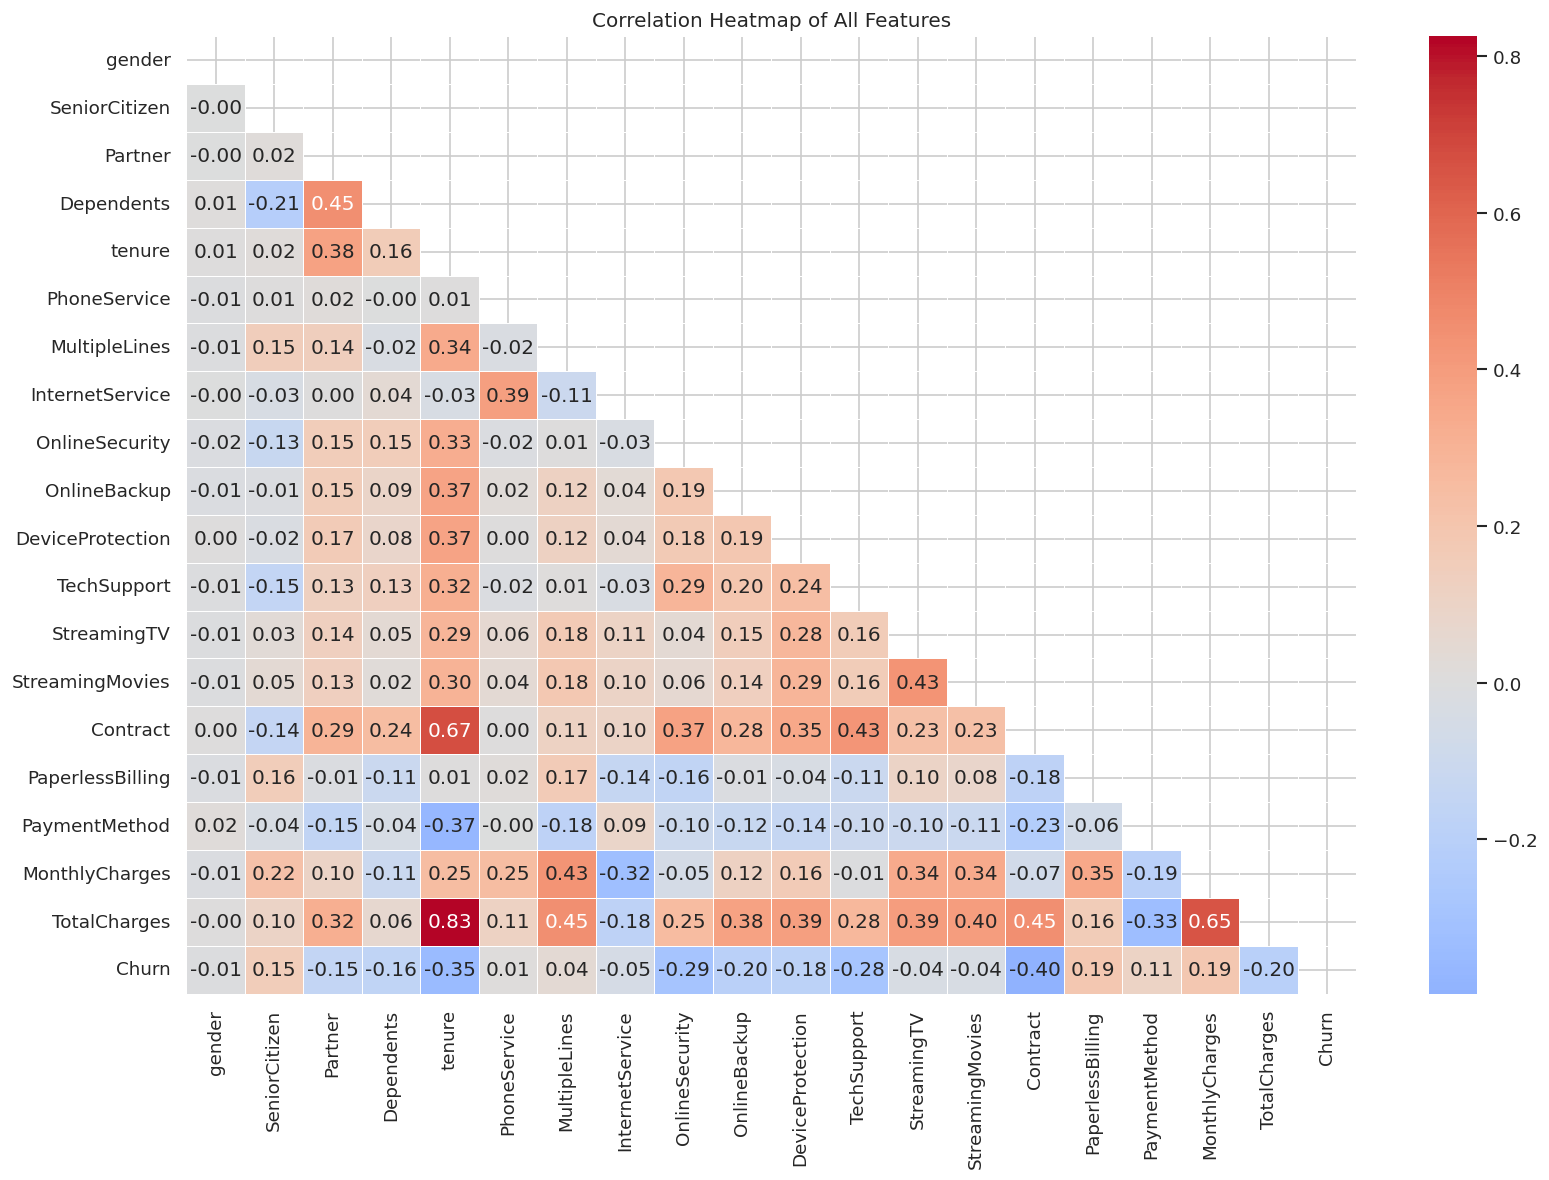

In [ ]:
# ============================================================
# CHART 5: Correlation Heatmap
# Encodes all binary/ordinal variables to reveal linear
# relationships. Tenure negatively correlates with churn;
# MonthlyCharges positively correlates with churn.
# ============================================================
df_enc = df_cleaned.drop('customerID', axis=1).copy()
df_enc['TotalCharges'] = pd.to_numeric(df_enc['TotalCharges'], errors='coerce')
for col in df_enc.select_dtypes('object').columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

plt.figure(figsize=(14, 10))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.show()

#### Observations: Correlation Heatmap

- **Tenure** shows a **strong negative correlation with Churn**, meaning customers who stay longer are much less likely to churn — consistent with findings from previous charts.
- **Monthly Charges** has a **positive correlation with Churn**, suggesting that higher billing amounts are associated with increased churn risk.
- **Total Charges** is highly correlated with **tenure** (r ≈ 0.83), which is expected since total charges accumulate over time — these two features may introduce **multicollinearity** in predictive models.
- Several service-related features (e.g., `StreamingTV`, `StreamingMovies`, `OnlineBackup`) are moderately correlated with each other, indicating that customers who subscribe to one add-on are likely to subscribe to others.
- `SeniorCitizen` shows a mild positive correlation with churn.

### Chart 6: Demographic Factors vs Churn

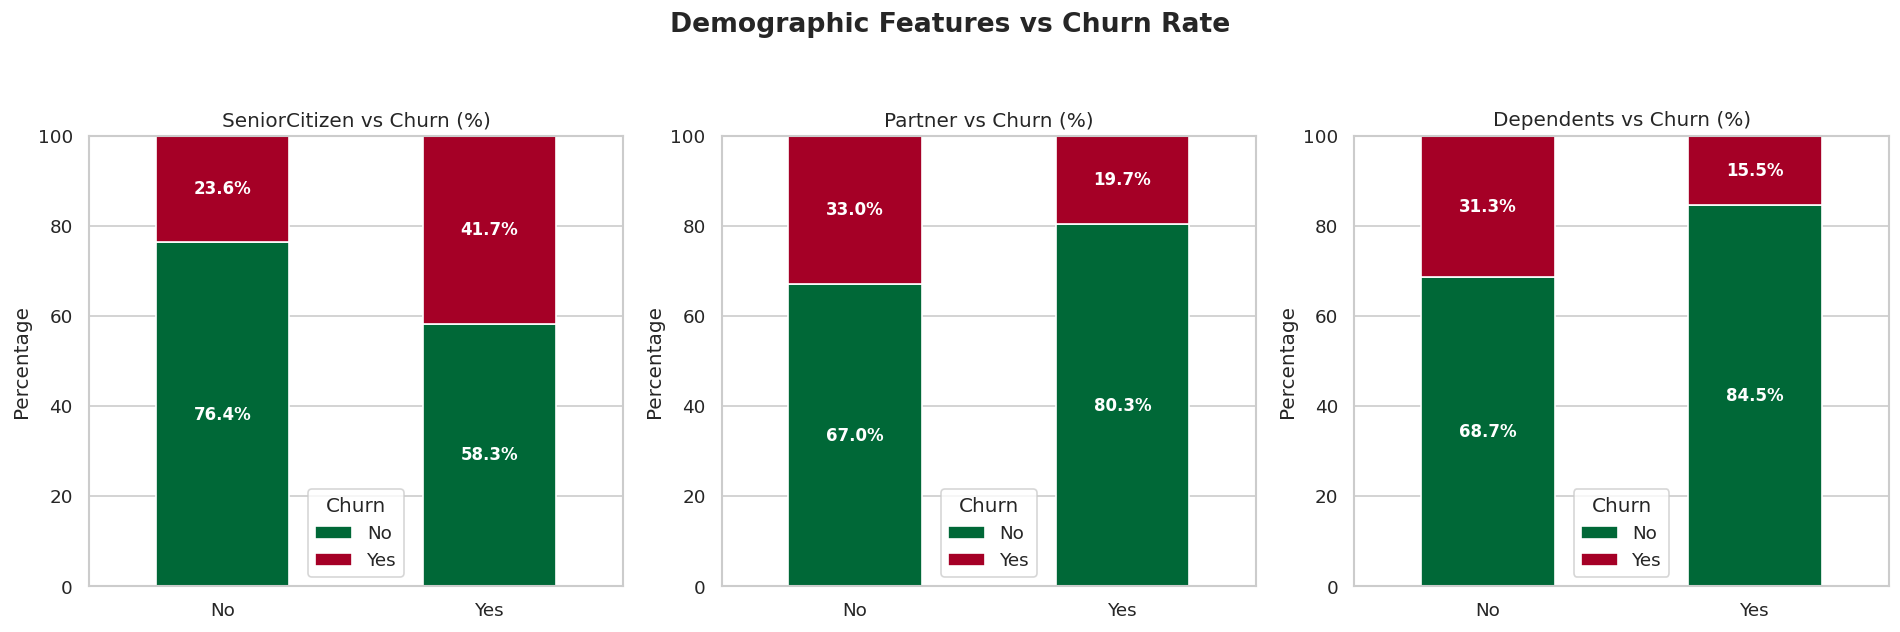

In [ ]:
# ============================================================
# CHART 6: Demographic Factors vs Churn
# Senior citizens churn at ~42% vs ~26% overall.
# Customers without partners/dependents are more likely to churn
# — they may have less "stickiness" to the service.
# ============================================================
demo_cols = ['SeniorCitizen', 'Partner', 'Dependents']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(demo_cols):
    cross = pd.crosstab(df_cleaned[col], df_cleaned['Churn'], normalize='index') * 100
    ax = axes[i]

    # Plot the stacked bar chart
    cross.plot(kind='bar', stacked=True, colormap='RdYlGn_r',
               ax=ax, rot=0)

    ax.set_title(f'{col} vs Churn (%)')
    ax.set_ylabel('Percentage')
    ax.set_xlabel('')
    ax.legend(title='Churn')

    # Add percentage labels inside the bars
    for container in ax.containers:
        for j, bar_patch in enumerate(container.patches):
            percentage = bar_patch.get_height()
            if percentage > 0: # Only label non-zero segments
                x = bar_patch.get_x() + bar_patch.get_width() / 2
                y = bar_patch.get_y() + percentage / 2 # Center of the segment
                ax.text(x, y, f'{percentage:.1f}%', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

    # Adjust y-axis limit to create more whitespace above the labels (if needed)
    ax.set_ylim(0, 100) # Stacked bars always go to 100%

plt.suptitle('Demographic Features vs Churn Rate', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

#### Observations: Demographic Factors vs Churn

- **Senior Citizens** (coded as 1) have a churn rate of approximately **42%**, nearly double the rate of non-senior customers (~24%). This group may require dedicated support or simpler service plans.
- Customers **without a partner** churn at a higher rate than those with one, possibly reflecting lower household financial stability or fewer shared service commitments.
- Similarly, customers **without dependents** show a higher churn tendency — those with dependents may value service continuity more highly.
- These demographic factors suggest that **single, senior, and independent-living customers** form a high-risk segment that deserves targeted retention efforts.

### Chart 7: MonthlyCharges vs Tenure colored by Churn

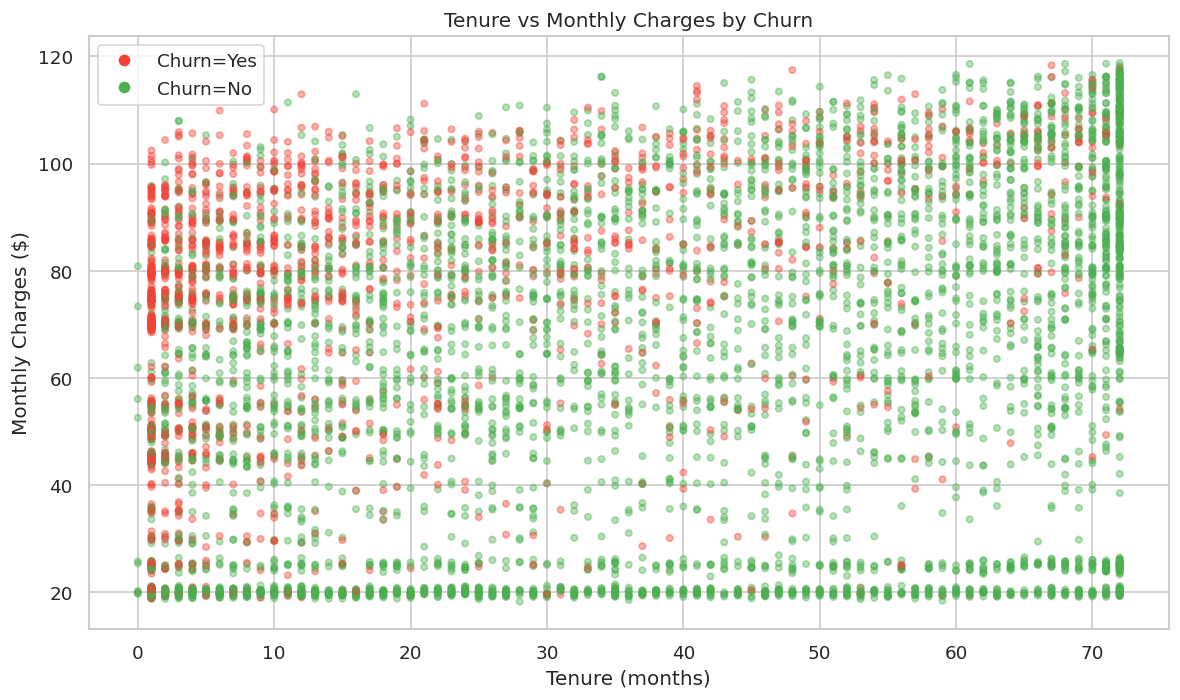

In [ ]:
# ============================================================
# CHART 7: MonthlyCharges vs Tenure colored by Churn
# High charges + low tenure = highest churn risk zone.
# Long-tenure customers seem to tolerate higher charges better.
# This chart reveals natural customer clusters.
# ============================================================
plt.figure(figsize=(10, 6))
colors = df_cleaned['Churn'].map({'Yes': '#F44336', 'No': '#4CAF50'})
plt.scatter(df_cleaned['tenure'], df_cleaned['MonthlyCharges'], c=colors, alpha=0.4, s=15)
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges ($)')
plt.title('Tenure vs Monthly Charges by Churn')
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w',
                   markerfacecolor='#F44336', markersize=8, label='Churn=Yes'),
                   Line2D([0], [0], marker='o', color='w',
                   markerfacecolor='#4CAF50', markersize=8, label='Churn=No')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

#### Observations: Monthly Charges vs Tenure (Colored by Churn)

- A clear **high-risk zone** is visible in the **top-left region** of the plot (high monthly charges, low tenure), which is densely populated by **churned customers** (red dots).
- Retained customers (green) are more broadly distributed, with a notable concentration in the **high-tenure, moderate-to-high charge** area — indicating that long-term customers accept higher prices more readily.
- Customers with **low monthly charges and low tenure** show mixed behavior, suggesting that price alone does not fully explain early churn.
- This scatter plot visually validates the hypothesis that **the combination of high cost and short relationship duration is the strongest churn indicator**.

### Chart 8: Churn Rate by Add-on Services

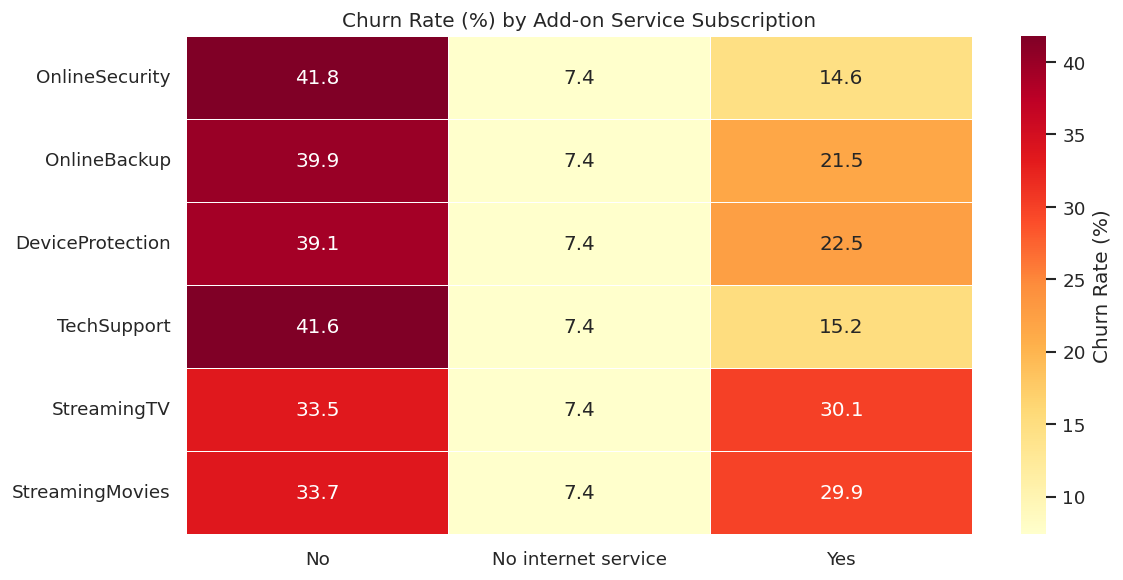

In [ ]:
# ============================================================
# CHART 8: Churn Rate by Add-on Services
# Customers WITHOUT OnlineSecurity and TechSupport churn more.
# These protective services act as "lock-in" features.
# Recommendation: promote security/support add-ons to at-risk users.
# ============================================================
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']
churn_by_service = {}
for s in services:
    churn_by_service[s] = df_cleaned.groupby(s)['Churn'].apply(
        lambda x: (x=='Yes').mean()*100).to_dict()

service_df = pd.DataFrame(churn_by_service).T
plt.figure(figsize=(10, 5))
sns.heatmap(service_df, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate (%) by Add-on Service Subscription')
plt.tight_layout()
plt.show()

#### Observations: Churn Rate by Add-on Services

- Customers who have **no OnlineSecurity** or **no TechSupport** exhibit the highest churn rates (approximately 42%), while those subscribed to these services churn at roughly half that rate (~15%).
- This pattern suggests that security and support add-ons function as **"stickiness" features** — they increase perceived value and create a stronger dependency on the service.
- Streaming services (TV and Movies) show a more moderate effect on churn, implying they are **entertainment-driven** rather than retention-driving features.
- **Business recommendation**: Promoting **OnlineSecurity** and **TechSupport** to at-risk customer segments could be an effective retention lever.

### Chart 9: Churn by Contract Type & Payment Method

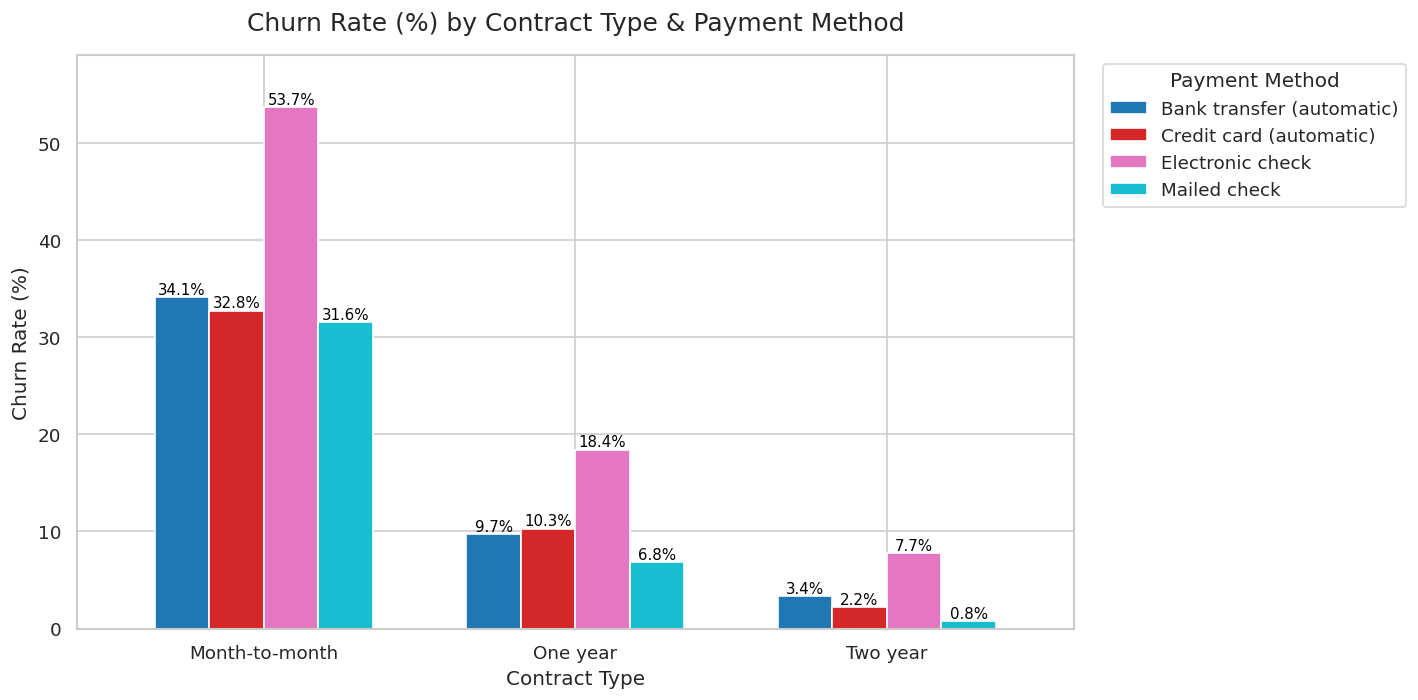

In [ ]:
# ============================================================
# CHART 9: Churn by Contract Type & Payment Method
# Month-to-month + Electronic check = highest churn combination.
# Two-year contracts drastically reduce churn across all payment types.
# This supports a long-term contract incentive strategy.
# ============================================================
# Calculate churn rate percentage using crosstab
cross = pd.crosstab(
    index=df_cleaned['Contract'],
    columns=df_cleaned['PaymentMethod'],
    values=(df_cleaned['Churn'] == 'Yes').astype(int),
    aggfunc='mean'
) * 100

# Plot directly using Pandas plotting (wrapper for Matplotlib)
# This avoids seaborn warnings and handles grouped bars perfectly
ax = cross.plot(kind='bar', colormap='tab10', figsize=(12, 6), rot=0, width=0.7)

# Set professional titles and labels
plt.title('Churn Rate (%) by Contract Type & Payment Method', fontsize=15, pad=15)
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)

# Add percentage labels on top of the bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9, color='black')

# Adjust y-axis limit to create more whitespace above the labels
max_churn_rate = cross.values.max()
ax.set_ylim(0, max_churn_rate * 1.1) # Set y-limit to 10% above max churn rate

# Adjust legend to be outside the plot area so it doesn't cover the bars
plt.legend(title='Payment Method', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

# Ensure tight layout so the legend is not cut off
plt.tight_layout()
plt.show()

#### Observations: Churn Rate by Contract Type & Payment Method

- The **month-to-month + electronic check** combination consistently yields the **highest churn rate** across all payment methods, approaching approximately 54%.
- Across all payment methods, **two-year contract holders churn at very low rates (< 8%)**, demonstrating the strong protective effect of long-term commitments regardless of how customers pay.
- Automatic payment methods (bank transfer and credit card) are associated with lower churn even within the month-to-month contract group, suggesting that **payment automation itself may contribute to retention**.
- Customers using **mailed check** show a moderate churn rate under month-to-month contracts (~31.6%), but this rate declines sharply for one-year and especially two-year contracts. This suggests that mailed check users may become relatively stable once they commit to longer-term plans.
- This chart reinforces the strategic value of **incentivizing customers to switch to longer contracts and automated billing**.

### Chart 10: Churn Rate Deviation by Feature Value

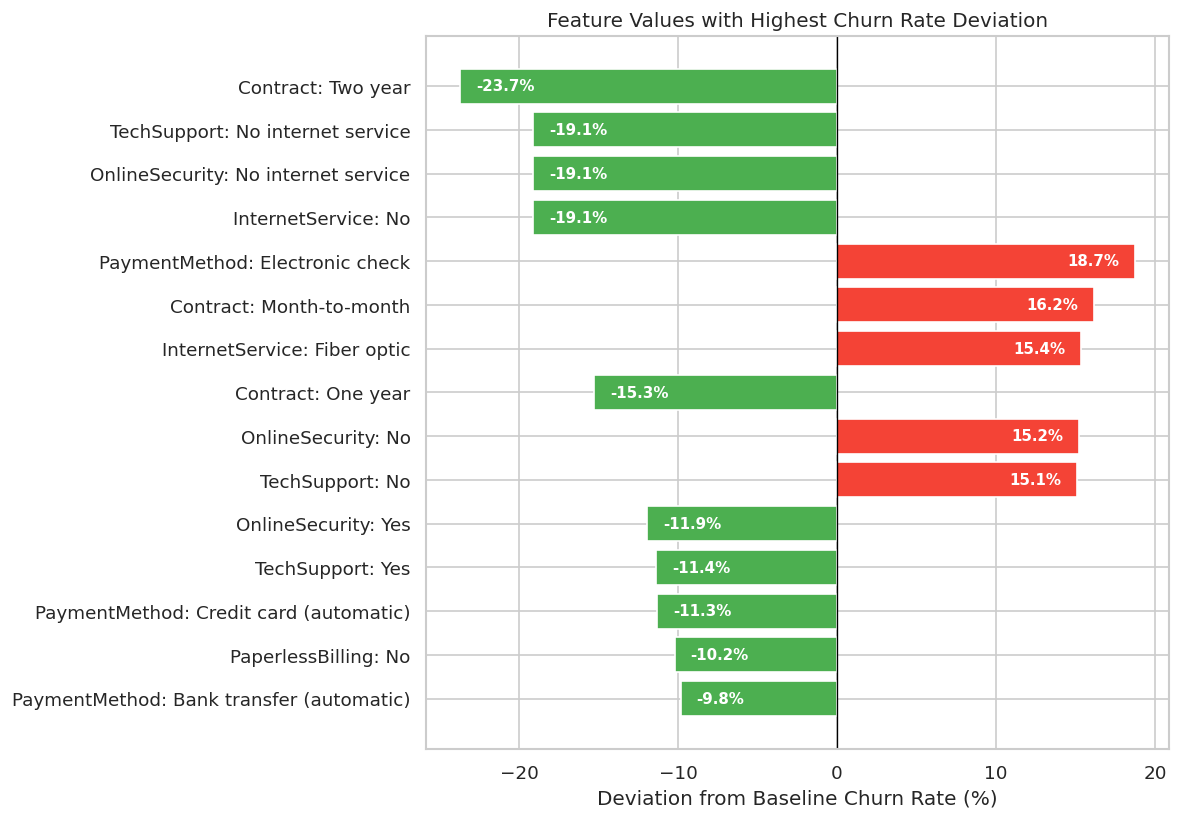

In [ ]:
# ============================================================
# CHART 10: Churn Rate Deviation by Feature Value
# Ranks which feature-value combinations deviate most from the
# baseline churn rate (26.5%). Useful for business prioritization.
# ============================================================
baseline = (df_cleaned['Churn'] == 'Yes').mean() * 100
results = []
cat_cols = ['Contract', 'InternetService', 'PaymentMethod',
            'OnlineSecurity', 'TechSupport', 'Partner', 'PaperlessBilling']

for col in cat_cols:
    for val, grp in df_cleaned.groupby(col):
        rate = (grp['Churn'] == 'Yes').mean() * 100
        results.append({'Feature': f'{col}: {val}', 'ChurnRate': rate,
                        'Deviation': rate - baseline})

res_df = pd.DataFrame(results).sort_values('Deviation', key=abs, ascending=False).head(15)
colors = ['#F44336' if x > 0 else '#4CAF50' for x in res_df['Deviation']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(res_df['Feature'], res_df['Deviation'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Deviation from Baseline Churn Rate (%)')
ax.set_title('Feature Values with Highest Churn Rate Deviation')

# Add percentage labels inside the bars
TEXT_OFFSET = 1.0 # Offset in data units for text inside bars
for bar in bars:
    width = bar.get_width() # This is the deviation value
    y_center = bar.get_y() + bar.get_height() / 2

    label = f'{width:.1f}%'

    if width >= 0:
        # For positive bars, text near the right end, inside
        x_text = width - TEXT_OFFSET
        ax.text(x_text, y_center, label, va='center', ha='right', color='white', fontweight='bold', fontsize=9)
    else:
        # For negative bars, text near the left end, inside
        x_text = width + TEXT_OFFSET
        ax.text(x_text, y_center, label, va='center', ha='left', color='white', fontweight='bold', fontsize=9)

ax.invert_yaxis() # To have the highest deviation at the top, consistent with sort_values(ascending=False)

plt.tight_layout()
plt.show()

#### Observations: Feature Values with Highest Churn Rate Deviation

- **Two-year contract** has the largest negative deviation at **-23.7%**, meaning customers on this plan churn at a rate nearly 24 percentage points *below* the baseline (~26.5%) — making it the single most protective feature in the dataset.
- On the positive side, **PaymentMethod: Electronic check (+18.7%)**, **Contract: Month-to-month (+16.2%)**, and **InternetService: Fiber optic (+15.4%)** are the top three features most strongly associated with churn — customers with these characteristics are at the highest risk.
- The absence of protective add-ons also stands out: **OnlineSecurity: No (+15.2%)** and **TechSupport: No (+15.1%)** nearly match Fiber optic in churn deviation, reinforcing that these services act as meaningful retention tools.
- Customers with **no internet service at all (-19.1%)** show one of the lowest churn rates, suggesting that simpler, lower-cost plans reduce the likelihood of switching.
- **PaperlessBilling: No (-10.2%)** and **automatic payment methods** (Credit card: -11.3%, Bank transfer: -9.8%) consistently fall below baseline, indicating that traditional billing and autopay habits correlate with greater customer stability.

### 🔍 Key Insights from Exploratory Data Analysis

---

**Insight 1: Customer Tenure is the Strongest Retention Indicator**

- Customers who churned had a median tenure of approximately **10 months**, compared to **38 months** for retained customers — indicating a substantial gap in customer longevity.
- The churn distribution is heavily concentrated in the **first 12 months**, after which the probability of churning drops significantly.
- **Implication**: The early relationship stage is the most critical window for retention efforts. Onboarding programs, welcome discounts, or proactive check-ins during the first year could substantially reduce churn.

---

**Insight 2: Contract Type is the Most Actionable Predictor**

- Month-to-month customers churn at **~43%**, while one-year and two-year contract holders churn at only **~11%** and **~3%** respectively.
- Two-year contracts show the largest negative deviation from the baseline churn rate at **-23.7%** (Chart 10), making it the single most protective feature in the dataset.
- **Implication**: Incentivizing customers to commit to longer contracts — through discounts, bundled benefits, or loyalty rewards — is likely the highest-ROI retention strategy available.

---

**Insight 3: High Monthly Charges Without Perceived Value Drive Churn**

- Churned customers are disproportionately concentrated in the **$70–$100+ monthly charge range** (Chart 2), yet Fiber optic users — who typically pay more — churn at **~42%** (Chart 3).
- The scatter plot (Chart 7) reveals a clear high-risk zone: **high monthly charges combined with low tenure**, suggesting customers leave before feeling they get sufficient value for the price.
- **Implication**: Pricing transparency, introductory rate programs, or service quality improvements for Fiber optic plans could help align cost with perceived value.

---

**Insight 4: Absence of Protective Add-ons Signals Churn Risk**

- Customers without **OnlineSecurity** and **TechSupport** churn at rates exceeding **42%**, compared to roughly **15%** for those who have subscribed to these services (Chart 8).
- These two features deviate from the baseline churn rate by **+15.2%** and **+15.1%** respectively (Chart 10) — nearly as impactful as Fiber optic internet.
- **Implication**: These add-ons act as "stickiness" features that increase perceived value and dependency. Proactively offering them — especially to new or at-risk customers — could serve as an effective churn prevention tool.

---

**Insight 5: Payment Method Reflects Customer Engagement Level**

- Customers paying via **electronic check churn at ~45%** — the highest of any payment method — and show a deviation of **+18.7%** from baseline, the largest positive deviation of all features (Chart 10).
- In contrast, customers using **automatic payment methods** (bank transfer: -9.8%, credit card: -11.3%) churn well below the baseline rate.
- Senior citizens, who make up a disproportionately high-churn demographic (~42%), may be more likely to rely on manual payment methods, compounding their risk.
- **Implication**: Encouraging customers to switch to automatic billing — through small incentives or simplified setup — could reduce churn while also improving payment reliability for the business.


## Step 4. Data preprocessing

In [ ]:
#Import Libraries for training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    roc_curve, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Load Cleaned Data

df = pd.read_csv('telco_churn_cleaned.csv')

print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nChurn distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Dataset shape: (7043, 21)

Data types:
customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46%
Yes    26.54%
Name: proportion, dtype: object


### 4.1. Feature Selection

We drop 'customerID' because it is a unique identifier with no predictive value. All remaining columns are kept as features since EDA showed they are relevant to churn behavior.

In [ ]:
# Feature Selection
df.drop(columns=['customerID'], inplace=True)

# Separate features (X) and target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

print("Features used:", list(X.columns))
print("\nTarget variable:", y.name)
print("Target classes:", y.unique())

Features used: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Target variable: Churn
Target classes: ['No' 'Yes']


### 4.2. Handling Categorical Variables

- Binary columns (Yes/No): encoded with LabelEncoder (0/1)
- Multi-class columns (3+ categories): encoded with pd.get_dummies (One-Hot Encoding) to avoid implying ordinal relationships between categories.
- Target variable 'Churn' is also label-encoded (No=0, Yes=1)

In [ ]:
# --- Encode target variable ---
le = LabelEncoder()
y = le.fit_transform(y)   # No → 0, Yes → 1
print("Target encoded: No=0, Yes=1")

# --- Identify column types ---
binary_cols = [col for col in X.columns
               if X[col].nunique() == 2 and X[col].dtype == 'object']

multi_cols  = [col for col in X.columns
               if X[col].nunique() > 2 and X[col].dtype == 'object']

print(f"\nBinary columns  (LabelEncoder): {binary_cols}")
print(f"Multi  columns  (One-Hot):      {multi_cols}")

# --- Label encode binary columns ---
for col in binary_cols:
    X[col] = le.fit_transform(X[col])

# --- One-Hot encode multi-class columns ---
X = pd.get_dummies(X, columns=multi_cols, drop_first=True)

print(f"\nFinal feature matrix shape: {X.shape}")
print(X.head(2))

Target encoded: No=0, Yes=1

Binary columns  (LabelEncoder): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi  columns  (One-Hot):      ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

Final feature matrix shape: (7043, 30)
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  PaperlessBilling  MonthlyCharges  TotalCharges  MultipleLines_No phone service  \
0       0              0        1           0       1             0                 1           29.85         29.85                            True   
1       1              0        0           0      34             1                 0           56.95       1889.50                           False   

   MultipleLines_Yes  InternetService_Fiber optic  InternetService_No  OnlineSecurity_No internet service  OnlineSecurity_Yes  \
0              False      

### 4.3. Train/test split

We use an 80/20 split and stratify on 'y' to preserve the class ratio (≈26% churn) in both subsets.
- Scaling: StandardScaler is applied ONLY for Logistic Regression, which is sensitive to feature magnitude.
- Gradient Boosting is tree-based and does NOT require scaling, so we keep an unscaled copy for it.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"Churn rate — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")


Training set : 5634 samples
Test set     : 1409 samples
Churn rate — Train: 26.54% | Test: 26.54%


### 4.4. Scaling

In [ ]:
# --- Scaling for Logistic Regression ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)         # transform test
print("\nScaling applied for Logistic Regression.")
print("Raw (unscaled) data kept for Gradient Boosting.")


Scaling applied for Logistic Regression.
Raw (unscaled) data kept for Gradient Boosting.


## Step 5. Modeling

### 5.1. Logistic Regression
Logistic Regression is chosen as the BASELINE model because:
- It is simple, fast, and highly interpretable.

- Coefficients directly show the direction and magnitude of each feature's effect on churn probability.
-  It serves as a good reference benchmark.
-  We use class_weight='balanced' to handle the class imbalance (~74% No-churn vs ~26% Churn).

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)
lr_pred  = lr_model.predict(X_test_scaled)
lr_prob  = lr_model.predict_proba(X_test_scaled)[:, 1]
print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


### 5.2. Gradient Boosting
Gradient Boosting is chosen as the ADVANCED model because:
- It builds trees sequentially, each correcting prior errors.
- It handles non-linear relationships and feature interactions that Logistic Regression may miss.
- It typically achieves higher predictive accuracy on tabular data with mixed feature types.


Hyperparameters:
- n_estimators=200  → number of boosting rounds
- learning_rate=0.05 → shrinkage to prevent overfitting
- max_depth=4       → tree complexity per round
- subsample=0.8     → stochastic sampling for regularization


In [ ]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


## Step 6. Model evaluation
We evaluate both models using:
- Accuracy  — overall correct predictions
- Precision — of predicted churners, how many actually churned
- Recall    — of actual churners, how many did we catch
- F1-score  — harmonic mean of Precision & Recall
- ROC-AUC   — probability ranking quality across all thresholds

For churn, RECALL is especially important: missing a churner (False Negative) is more costly than a false alarm.


In [ ]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        'Model'     : name,
        'Accuracy'  : accuracy_score(y_true, y_pred),
        'Precision' : precision_score(y_true, y_pred),
        'Recall'    : recall_score(y_true, y_pred),
        'F1-Score'  : f1_score(y_true, y_pred),
        'ROC-AUC'   : roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    evaluate_model('Logistic Regression', y_test, lr_pred, lr_prob),
    evaluate_model('Gradient Boosting',   y_test, gb_pred, gb_prob)
]).set_index('Model').round(4)

print("=" * 60)
print("         MODEL PERFORMANCE COMPARISON")
print("=" * 60)
print(results.to_string())
print("=" * 60)

         MODEL PERFORMANCE COMPARISON
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.7388     0.5052  0.7807    0.6134   0.8412
Gradient Boosting      0.8041     0.6678  0.5214    0.5856   0.8430


Confusion Matrices
- True Negative  (TN) — correctly predicted No-Churn
- False Positive (FP) — predicted Churn, actually No-Churn
- False Negative (FN) — predicted No-Churn, actually Churn
- True Positive  (TP) — correctly predicted Churn

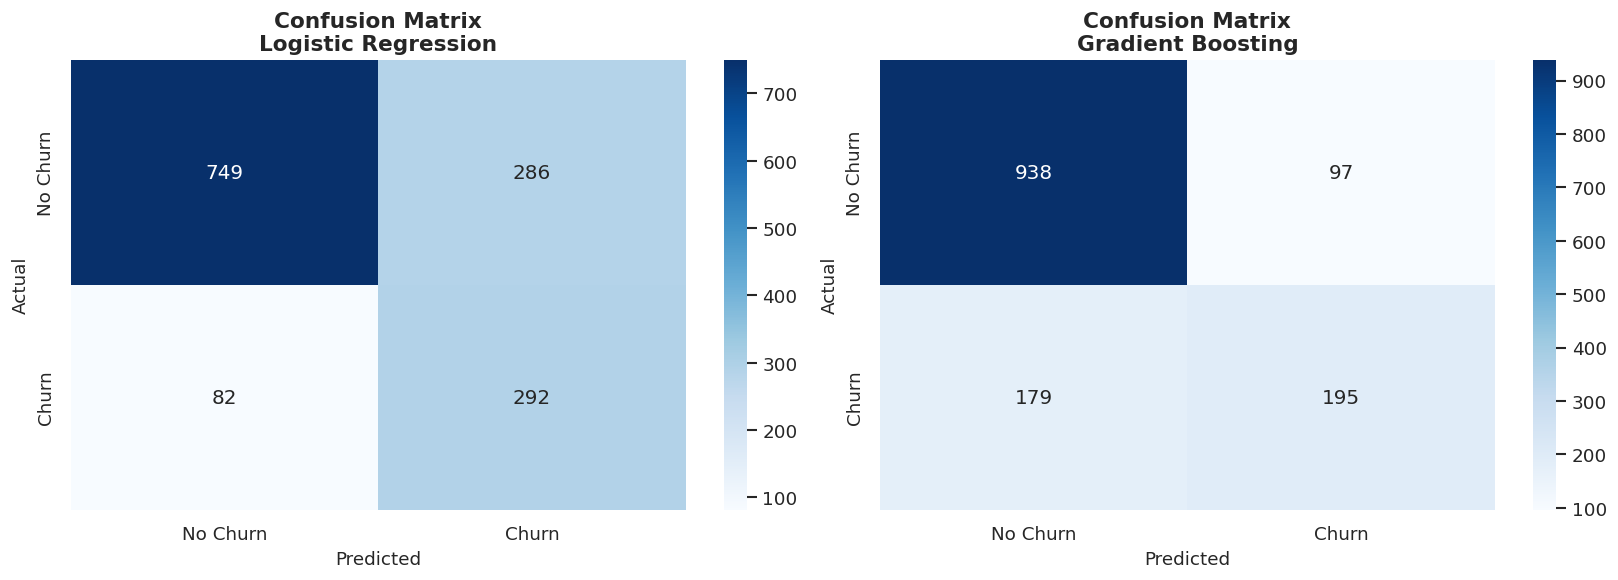

Confusion matrices plotted.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred) in zip(
    axes,
    [('Logistic Regression', lr_pred), ('Gradient Boosting', gb_pred)]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn']
    )
    ax.set_title(f'Confusion Matrix\n{name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11)
    plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices plotted.")

ROC Curves
- The ROC curve plots True Positive Rate vs False Positive Rate at every classification threshold. A higher AUC means the model ranks churners above non-churners more consistently.
- The diagonal line represents a random (coin-flip) classifier.

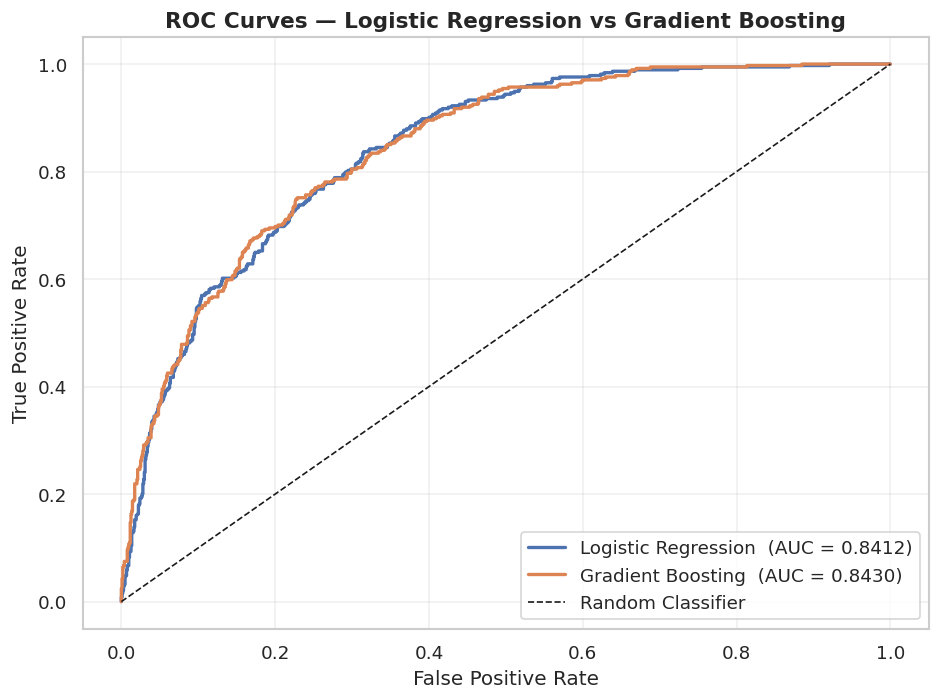

In [ ]:
plt.figure(figsize=(8, 6))

for name, y_prob in [('Logistic Regression', lr_prob),
                      ('Gradient Boosting',   gb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name}  (AUC = {auc:.4f})')

plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate',  fontsize=12)
plt.title('ROC Curves — Logistic Regression vs Gradient Boosting',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("=" * 55)
print("   CLASSIFICATION REPORT — Logistic Regression")
print("=" * 55)
print(classification_report(y_test, lr_pred,
      target_names=['No Churn', 'Churn']))

print("=" * 55)
print("   CLASSIFICATION REPORT — Gradient Boosting")
print("=" * 55)
print(classification_report(y_test, gb_pred,
      target_names=['No Churn', 'Churn']))

   CLASSIFICATION REPORT — Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

   CLASSIFICATION REPORT — Gradient Boosting
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [ ]:
print("=" * 55)
print("        OVERFITTING / UNDERFITTING CHECK")
print("=" * 55)

for name, model, Xtr, Xte in [
    ('Logistic Regression', lr_model, X_train_scaled, X_test_scaled),
    ('Gradient Boosting',   gb_model, X_train,        X_test)
]:
    train_acc = accuracy_score(y_train, model.predict(Xtr))
    test_acc  = accuracy_score(y_test,  model.predict(Xte))
    gap       = train_acc - test_acc
    verdict   = ("Possible Overfitting" if gap > 0.05
                 else "Well Generalised")
    print(f"\n{name}")
    print(f"  Train Accuracy : {train_acc:.4f}")
    print(f"  Test  Accuracy : {test_acc:.4f}")
    print(f"  Gap            : {gap:.4f}  →  {verdict}")

print("=" * 55)

        OVERFITTING / UNDERFITTING CHECK

Logistic Regression
  Train Accuracy : 0.7515
  Test  Accuracy : 0.7388
  Gap            : 0.0127  →  Well Generalised

Gradient Boosting
  Train Accuracy : 0.8470
  Test  Accuracy : 0.8041
  Gap            : 0.0429  →  Well Generalised


Q1: Which model performs better?                       

It depends on the evaluation metric. Gradient Boosting outperforms
Logistic Regression in Accuracy (0.8041 vs 0.7388), Precision
(0.6678 vs 0.5052), and ROC-AUC (0.8430 vs 0.8412). However,
Logistic Regression achieves a higher Recall (0.7807 vs 0.5214)
and F1-Score (0.6134 vs 0.5856) for the Churn class, meaning it
detects more actual churners despite more false alarms.



Q2: Which model is more suitable for this problem?

For customer churn, Logistic Regression is arguably more suitable
from a business perspective. Missing a churner (False Negative) is
more costly than a false alarm — losing a customer is harder to
recover from than offering a retention discount unnecessarily.
LR's higher Recall (0.78) means it catches 78% of actual churners
vs only 52% for Gradient Boosting.
That said, if the business prioritises precision (only contacting
high-confidence churners), Gradient Boosting is preferable.


Q2: Is there any sign of overfitting or underfitting?

No significant overfitting detected in either model. Logistic Regression: Train=0.7515, Test=0.7388 → Gap=0.0127
Gradient Boosting:   Train=0.8470, Test=0.8041 → Gap=0.0429
Both gaps are below the 0.05 threshold, indicating both models
generalise well to unseen data.

Q4: Important variables?

- tenure — churned customers had a median tenure of only 10 months vs 38 months for retained customers; churn risk drops sharply after the first 12 months
- MonthlyCharges & TotalCharges — churned customers are concentrated in the $70–$100+ monthly charge range; high charges combined with low tenure form the strongest churn risk zone
- Contract type (Month-to-month) — churn rate of 42.7% vs 11.3% for one-year and only 2.8% for two-year contracts; the largest single protective feature in the dataset
- InternetService (Fiber optic) — Fiber optic users churn at 41.9% vs 19% for DSL, likely reflecting unmet quality expectations or pricing dissatisfaction
- Lack of OnlineSecurity and TechSupport — customers without these add-ons churn at ~42% vs ~15% for subscribers; both deviate +15% above baseline, acting as key "stickiness" features
- PaymentMethod (Electronic check) — highest churn rate of any payment method at 45.3%, with a +18.7% deviation above baseline; automatic payment methods (bank transfer, credit card) are consistently below baseline churn rate